In [32]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

In [ ]:
# import dataset CIFAR10

cifar_data = torchvision.datasets.CIFAR10(root="./data", download=True)    
print("___" * 30)
print(cifar_data)
print(cifar_data.data.shape)
print(cifar_data.classes)

d:\Pablo_Data\Documentos\VSCode\deep-learning\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


______________________________
Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
(50000, 32, 32, 3)
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


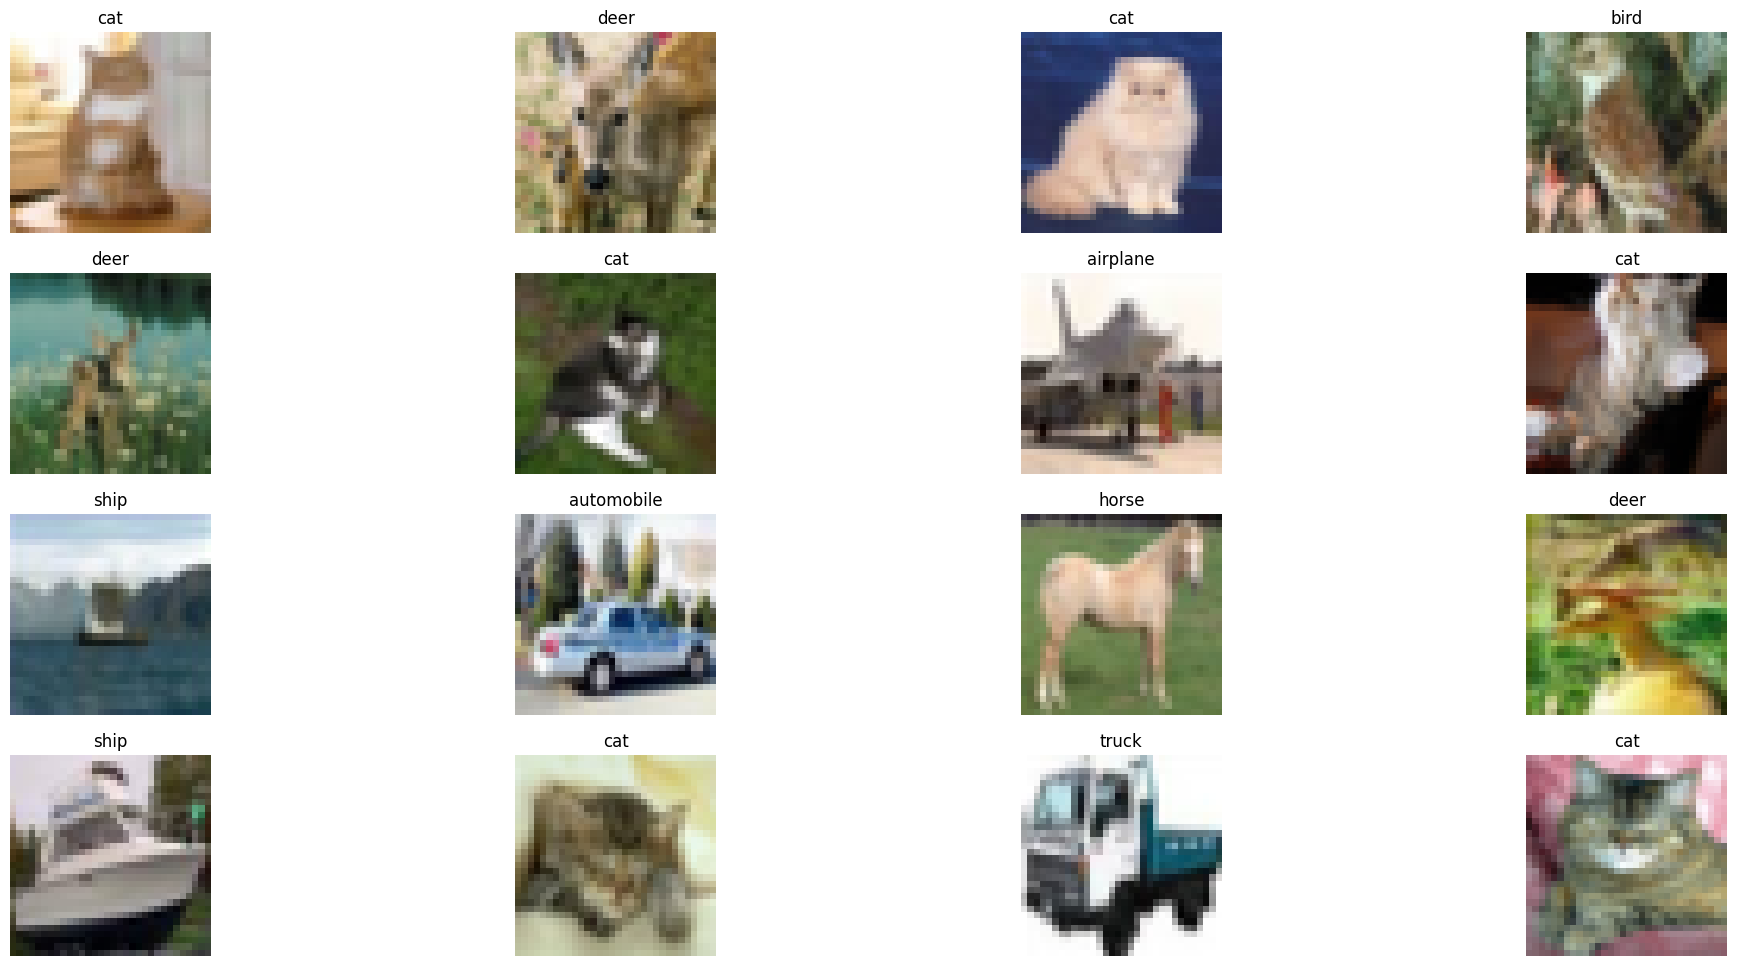

In [15]:
# inspect a few random images

from calendar import c


fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(25, 12))

for ax in ax.flatten():
    random_index = np.random.randint(0, len(cifar_data))
    image, label = cifar_data[random_index]
    label = cifar_data.classes[cifar_data.targets[random_index]]
    ax.imshow(image, label=label)
    ax.set_title(label)
    ax.axis("off")

In [ ]:
# apply transforms to dataset
# with ToTensor() there is no need of scaling
transform = T.Compose([ T.ToTensor(), # convert from a PIL image (or numpy array) to a PyTorch tensor and scale the pixel values from [0, 255] to [0, 1]
                        T.Resize(32*4), # resize the image to 4 times its original size (32x32 -> 128x128)
                        T.Grayscale(num_output_channels=1) # convert to grayscale, num_output_channels=1 means we want a single channel (black and white)
                        ]) 
# one way of applying transforms to a dataset is to pass the transform argument when creating the dataset
# cifar_data_transformed = torchvision.datasets.CIFAR10(root="./data", download=True, transform=transform)

# another way is to apply the transform to the dataset's data attribute directly, but it needs to be applied image by image
transformed_cifar_data = [transform(image) for image in cifar_data.data] # apply the transform to the dataset's data attribute

In [28]:
cifar_data.data[0].shape, transformed_cifar_data[0].shape

((32, 32, 3), torch.Size([1, 128, 128]))

Text(0.5, 1.0, 'Transformed image (Grayscale)')

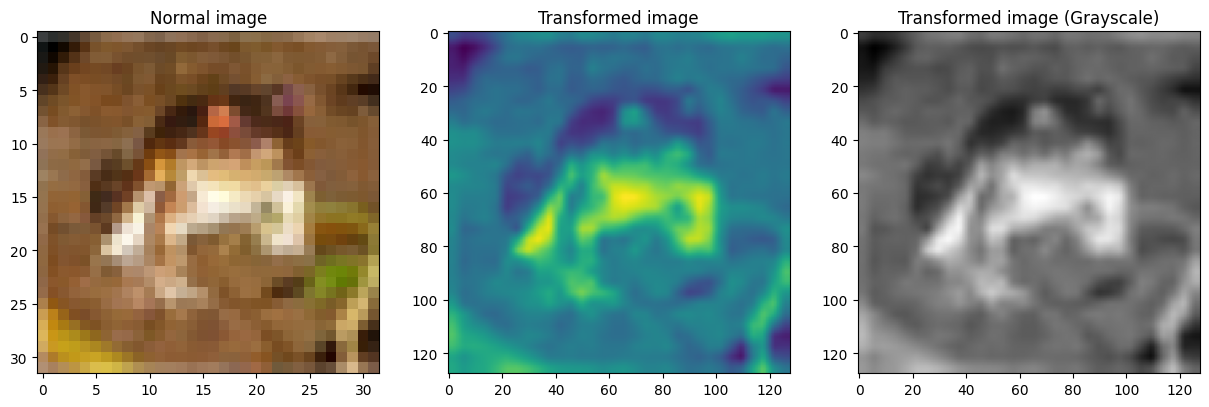

In [31]:
# plot an image from the normal and transformed dataset to compare
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# plot normal image
ax[0].imshow(cifar_data.data[0]) # 3 channels, so we can display it as a color image
ax[0].set_title("Normal image")

# plot transformed image
ax[1].imshow(transformed_cifar_data[0].squeeze()) # 1 channel, squeeze to remove the channel dimension, but we can still display it as a color image
ax[1].set_title("Transformed image")

# plot transformed image
ax[2].imshow(transformed_cifar_data[0].squeeze(), cmap="gray") # cmap="gray" to display as grayscale
ax[2].set_title("Transformed image (Grayscale)")

In [44]:
# MNIST dataset
mnist_data = torchvision.datasets.MNIST(root="./data", download=True) # already in grayscale, so no need to apply the Grayscale() transform
mnist_data.data.shape, mnist_data.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

In [45]:
class customDataset(Dataset):
    def __init__(self, data, targets, transform=None):
        # check if data and targets have the same length
        assert len(data) == len(targets), "Data and targets must have the same length"

        self.data = data
        self.targets = targets
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        image = self.data[index]
        label = self.targets[index]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [48]:
# Note: several transforms like RandomVerticalFlip work only with PIL images, so if you want to apply them to a dataset that has data in the form of numpy arrays, 
# you need to convert them to PIL images first. You can do this with the ToPILImage() transform. For example:

img_transform = T.Compose([T.ToPILImage(), # convert from a numpy array to a PIL image
                           T.RandomVerticalFlip(p=0.5), # randomly flip the image vertically with a probability of 0.5 to be fliped
                           T.ToTensor()]) # convert finally to a PyTorch tensor
    
train_data = customDataset(data=mnist_data.data, targets=mnist_data.targets, transform=img_transform)

data_loaded = DataLoader(train_data, batch_size=8, shuffle=False)

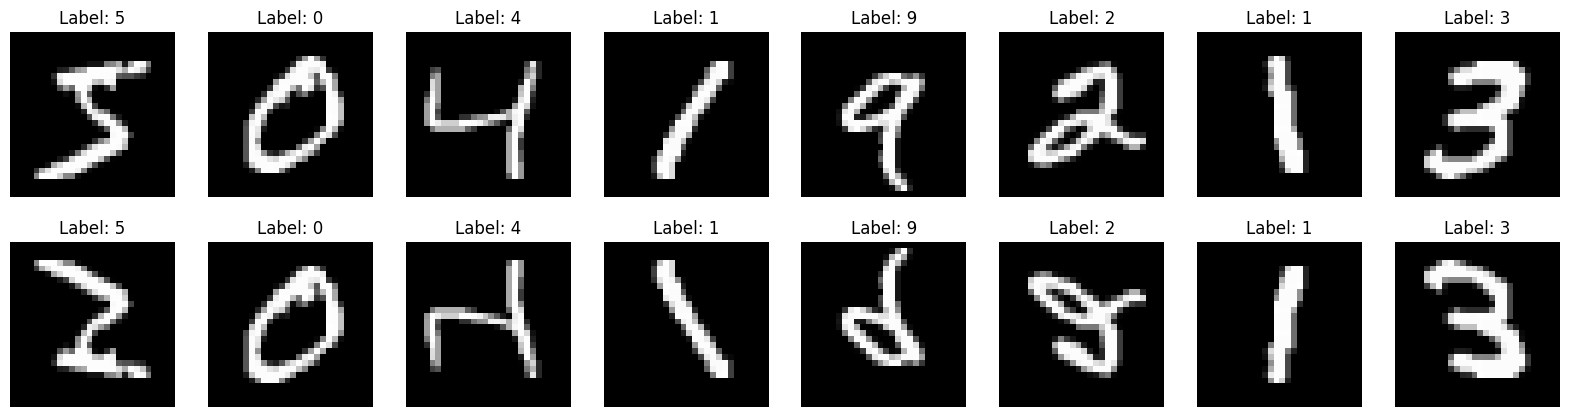

In [ ]:
X, y = next(iter(data_loaded))

fig, ax = plt.subplots(nrows=2, ncols=8, figsize=(20, 5))

# plot the original and transformed images in the first and second row respectively
for i in range(8):

    ax[0, i].imshow(mnist_data.data[i].squeeze(), cmap="gray") # squeeze to remove the channel dimension, cmap="gray" to display as grayscale
    ax[0, i].set_title(f"Label: {y[i].item()}")
    ax[0, i].axis("off")

    ax[1, i].imshow(X[i].squeeze(), cmap="gray") # squeeze to remove the channel dimension, cmap="gray" to display as grayscale
    ax[1, i].set_title(f"Label: {y[i].item()}")
    ax[1, i].axis("off")

    # not all of them must be flipped (there is a 50% chance of being flipped), so we can see some images flipped and some not flipped in the second row

    # we haven't increade the amount of data in the dataset, we have just applied a random transform to the existing data, so we still have 60,000 images
    # in the dataset, but some of them are randomly flipped versions of the original images.